In [8]:
%%bash
### Inphared genomovar clustering ###

# mkdir -p inphared
# cd inphared

# # download seqs
# wget https://millardlab-inphared.s3.climb.ac.uk/14Apr2025_genomes.fa.gz

# # dereplicate w/vclust
# vclust \
#     prefilter \
#     --in 14Apr2025_genomes.fa.gz \
#     --out 14Apr2025_genomes.vclust_derep_prefilter.txt \
#     --threads 36 \
#     --min-ident 0.99

# vclust \
#     align \
#     --in 14Apr2025_genomes.fa.gz \
#     --out 14Apr2025_genomes.vclust_derep_ani.tsv \
#     --filter 14Apr2025_genomes.vclust_derep_prefilter.txt \
#     --filter-threshold 0.995 \
#     --threads 36 \
#     --out-ani 0.995 \
#     --out-qcov 1.0

# vclust \
#     cluster \
#     --in 14Apr2025_genomes.vclust_derep_ani.tsv \
#     --ids 14Apr2025_genomes.vclust_derep_ani.ids.tsv \
#     --out 14Apr2025_genomes.vclust_derep_clusters.tsv \
#     --algorithm cd-hit \
#     --metric ani \
#     --ani 0.995 \
#     --qcov 1.0 \
#     --out-repr

In [9]:
### Load inphared data
# load table and treat all as complete
import polars as pl

db_sizes = []

db_sizes.append({
    'database': 'Inphared',
    'Complete': pl.read_csv('inphared/14Apr2025_genomes.vclust_derep_clusters.tsv', separator='\t', columns=['object', 'cluster']).unique('cluster').shape[0],
    'High-quality': 0
})

In [10]:
### CHVD size estimate
# already dereplicated at vOTU level
# !wget https://zenodo.org/records/4776317/files/HV3_table2_master_table.xlsx?download=1 -O chvd/HV3_table2_master_table.xlsx

import polars as pl

chvd = pl.read_excel('chvd/HV3_table2_master_table.xlsx')

db_sizes.append({
    'database': 'CHVD',
    'Complete': chvd.filter(pl.col('CheckV_estimated_completeness') == 100).shape[0],
    'High-quality': chvd.filter(pl.col('CheckV_estimated_completeness') >= 90).shape[0],
})

In [11]:
%%bash 
### MMGE download

# mkdir -p mmge
# cd mmge

# wget wget https://mai.fudan.edu.cn/mgedb/client/file/all_mge_inf.zip
# unzip all_mge_inf.zip

# wget https://mai.fudan.edu.cn/mgedb/client/file/all_mge_seq.zip
# unzip all_mge_seq.zip

In [12]:
### MMGE extract HQ virus seqs
import polars as pl

mmge = pl.read_csv('mmge/all_mge_inf.csv')

(
    mmge
        .filter(
            (pl.col('status').str.contains('phage')) &
            (pl.col('checkv_genome_quality').is_in(['High-quality', 'Complete']))
        )[['MGEs_id']]
        .write_csv('mmge/mmge_hq_virus_ids.txt', include_header=False)
)

In [13]:
%%bash
### MMGE genomovar clustering
# cd mmge/

# # extract HQ seqs
# seqkit grep \
#     all_mge_seq.fasta \
#     --pattern-file mmge_hq_virus_ids.txt \
#     -o mmge_hq_viruses.fna

# # dereplicate w/vclust
# vclust \
#     prefilter \
#     --in mmge_hq_viruses.fna \
#     --out mmge_hq_viruses.vclust_derep_prefilter.txt \
#     --threads 36 \
#     --min-ident 0.99

# vclust \
#     align \
#     --in mmge_hq_viruses.fna \
#     --out mmge_hq_viruses.vclust_derep_ani.tsv \
#     --filter mmge_hq_viruses.vclust_derep_prefilter.txt \
#     --filter-threshold 0.995 \
#     --threads 36 \
#     --out-ani 0.995 \
#     --out-qcov 1.0

# vclust \
#     cluster \
#     --in mmge_hq_viruses.vclust_derep_ani.tsv \
#     --ids mmge_hq_viruses.vclust_derep_ani.ids.tsv \
#     --out mmge_hq_viruses.vclust_derep_clusters.tsv \
#     --algorithm cd-hit \
#     --metric ani \
#     --ani 0.995 \
#     --qcov 1.0 \
#     --out-repr

In [14]:
### MMGE size estimate
mmge_reps = set(pl.read_csv('mmge/mmge_hq_viruses.vclust_derep_clusters.tsv', separator='\t', columns=['object', 'cluster'])['cluster'])
db_sizes.append({
    'database': 'mMGE',
    'Complete': mmge.filter((pl.col('checkv_genome_quality') == 'Complete') & (pl.col('MGEs_id').is_in(mmge_reps))).shape[0],
    'High-quality': mmge.filter((pl.col('checkv_genome_quality') == 'High-quality') & (pl.col('MGEs_id').is_in(mmge_reps))).shape[0],
})

In [15]:
%%bash
### UHGV genomovar clustering

# # identify UHGV HQ uncertain genomes
# wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/uhgv_metadata.tsv

# uhgv = pl.read_csv('uhgv_metadata.tsv', separator='\t', columns=['uhgv_genome', 'checkv_quality', 'viral_confidence'])
# (
#     uhgv
#         .filter(pl.col('checkv_quality').is_in(['High-quality', 'Complete']) & (pl.col('viral_confidence') == 'Uncertain'))[['uhgv_genome']]
#         .write_csv('uhgv_hq_plus_uncertain.tsv', include_header=False)
# )

# wget https://portal.nersc.gov/cfs/m342/UHGV/genome_catalogs/uhgv_full.fna.gz

# seqkit grep \
#     uhgv_full.fna.gz \
#     --pattern-file uhgv_hq_plus_uncertain.tsv \
#     --out-file uhgv_hq_plus_uncertain.fna.gz

# wget https://portal.nersc.gov/cfs/m342/UHGV/genome_catalogs/uhgv_hq_plus.fna.gz

# cat uhgv_hq_plus.fna.gz \
#     uhgv_hq_plus_uncertain.fna.gz \
#     > uhgv_hq_plus_confident_w_uncertain.fna.gz

# # run seqhasher to dereplicate genomes
# /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhgdb/bin/seq-hasher \
#     uhgv_hq_plus_confident_w_uncertain.fna.gz \
#     --multi-kmer-hashing \
#     --circular-kmers \
#     > uhgv_hq_plus_confident_w_uncertain.seq-hasher.tsv

# # identify unique sequences
# csvtk uniq \
#     uhgv_hq_plus_confident_w_uncertain.seq-hasher.tsv \
#     --no-header-row \
#     --fields 2 \
#     --tabs \
#     --out-file uhgv_hq_plus_confident_w_uncertain.uniq.tsv

# # extract unique sequences
# csvtk cut \
#     --tabs \
#     uhgv_hq_plus_confident_w_uncertain.uniq.tsv \
#     --fields 1 \
#     --out-file uhgv_hq_plus_confident_w_uncertain.unique_pattern.tsv

# seqkit \
#     grep \
#     --threads 2 \
#     --pattern-file uhgv_hq_plus_confident_w_uncertain.unique_pattern.tsv \
#     uhgv_hq_plus_confident_w_uncertain.fna.gz \
#     -o uhgv_hq_plus_confident_w_uncertain.unique.fna.gz

# # cluster unique sequences into genomovars
# vclust \
#     prefilter \
#     --in uhgv_hq_plus_confident_w_uncertain.unique.fna.gz \
#     --out uhgv_hq_plus_confident_w_uncertain.vclust_derep_prefilter.txt \
#     --threads 36 \
#     --min-ident 0.995

# vclust \
#     align \
#     --in uhgv_hq_plus_confident_w_uncertain.unique.fna.gz \
#     --out uhgv_hq_plus_confident_w_uncertain.vclust_derep_ani.tsv \
#     --filter uhgv_hq_plus_confident_w_uncertain.vclust_derep_prefilter.txt \
#     --threads 72 \
#     --out-ani 0.995 \
#     --out-qcov 1.0

# vclust \
#     cluster \
#     --in uhgv_hq_plus_confident_w_uncertain.vclust_derep_ani.tsv \
#     --ids uhgv_hq_plus_confident_w_uncertain.vclust_derep_ani.ids.tsv \
#     --out uhgv_hq_plus_confident_w_uncertain.vclust_derep_clusters.tsv \
#     --algorithm cd-hit \
#     --metric ani \
#     --ani 0.995 \
#     --qcov 1.0 \
#     --out-repr

In [16]:
### UHGV size estimate
uhgv = pl.read_csv('uhgv_metadata.tsv', separator='\t', columns=['uhgv_genome', 'checkv_quality', 'viral_confidence'])

uhgv_reps = set(pl.read_csv('uhgv/uhgv_hq_plus_confident_w_uncertain.vclust_derep_clusters.tsv', separator='\t', columns=['object', 'cluster'])['cluster'])

db_sizes.append({
    'database': 'UHGV',
    'Complete': uhgv.filter((pl.col('checkv_quality') == 'Complete')  & (pl.col('uhgv_genome').is_in(uhgv_reps))).shape[0],
    'High-quality': uhgv.filter((pl.col('checkv_quality') == 'High-quality') & (pl.col('uhgv_genome').is_in(uhgv_reps))).shape[0],
})

In [17]:
### IMGVR extract HQ human virus seqs
imgvr_human = (
    pl.read_csv('IMGVR_all_Sequence_information.tsv', separator='\t', columns=['UVIG', 'Topology', 'Ecosystem classification', 'MIUViG quality'])
        .filter(
            (pl.col('Ecosystem classification').str.contains('Human')) &
            (pl.col('MIUViG quality').is_in(['High-quality', 'Complete']))
        )
)
# !mkdir -p imgvr
# imgvr_human[['UVIG']].write_csv('imgvr/imgvr_human_hq_plus_ids.txt', include_header=False)

# extract HQ seqs
# !wget https://portal.nersc.gov/genomad/__data__/IMGVR_DATA/IMGVR4_SEQUENCES.fna
# !seqkit grep \
#     /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/uhvdb/mine/imgvr/IMGVR4_human_sequences.fna.gz \
#     --id-regexp "^(.*?)\|" \
#     --pattern-file imgvr/imgvr_human_hq_plus_ids.txt \
#     --out-file imgvr/imgvr_human_hq_plus.fna.gz

In [18]:
%%bash
### IMGVR genomovar clustering

# cd imgvr

# vclust \
#     prefilter \
#     --in imgvr_human_hq_plus.fna.gz \
#     --out imgvr_human_hq_plus.vclust_derep_prefilter.txt \
#     --threads 36 \
#     --min-ident 0.995

# vclust \
#     align \
#     --in imgvr_human_hq_plus.fna.gz \
#     --out imgvr_human_hq_plus.vclust_derep_ani.tsv \
#     --filter imgvr_human_hq_plus.vclust_derep_prefilter.txt \
#     --threads 36 \
#     --out-ani 0.995 \
#     --out-qcov 1.0

# vclust \
#     cluster \
#     --in imgvr_human_hq_plus.vclust_derep_ani.tsv \
#     --ids imgvr_human_hq_plus.vclust_derep_ani.ids.tsv \
#     --out imgvr_human_hq_plus.vclust_derep_clusters.tsv \
#     --algorithm cd-hit \
#     --metric ani \
#     --ani 0.995 \
#     --qcov 1.0 \
#     --out-repr

In [19]:
### IMGVR size estimate
imgvr_reps = set(
    pl.read_csv('imgvr/imgvr_human_hq_plus.vclust_derep_clusters.tsv', separator='\t', columns=['object', 'cluster'])
    .with_columns([pl.col('cluster').str.split('|').list[0]])['cluster']
)

db_sizes.append({
    'database': 'IMGVR',
    'Complete': imgvr_human.filter((pl.col('Topology') == 'Direct terminal repeat') & (pl.col('UVIG').is_in(imgvr_reps))).shape[0],
    'High-quality': imgvr_human.filter((pl.col('Topology') != 'Direct terminal repeat') & (pl.col('UVIG').is_in(imgvr_reps))).shape[0],
})

In [22]:
### UHVDB size estimate
import polars as pl
# filter mine report to only those in final uhvdb
uhvdb_genomovars = set(
    pl.read_csv('uhvdb.vclust_genomovars_reps.tsv', has_header=False, new_columns=['seq_name'])
        ['seq_name']
)

uhvdb = (
    pl.read_csv('viruses.csvtk_concat.tsv', separator='\t', columns=['seq_name', 'source_db', 'checkv_quality'])
        .filter(pl.col('seq_name').is_in(uhvdb_genomovars))
        .unique('seq_name')
)

db_sizes.append({
    'database': 'UHVDB',
    'Complete': uhvdb.filter(pl.col('checkv_quality') == 'Complete').shape[0],
    'High-quality': uhvdb.filter(pl.col('checkv_quality') == 'High-quality').shape[0],
})

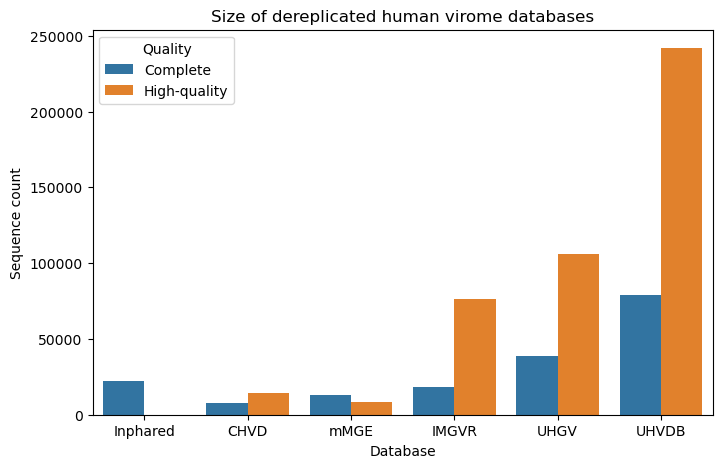

In [23]:
import seaborn as sns
import polars as pl
import matplotlib.pyplot as plt

plot_df = (
    pl.DataFrame(db_sizes)
        .rename({'database':'Database'})
        .unpivot(
            ['Complete', 'High-quality'],
            index='Database',
            variable_name='Quality',
            value_name='Sequence count'
        )
)

plt.figure(figsize=(8,5))
sns.barplot(data=plot_df, x='Database', hue='Quality', y='Sequence count', order=['Inphared', 'CHVD', 'mMGE', 'IMGVR', 'UHGV', 'UHVDB'])
plt.title('Size of dereplicated human virome databases')
plt.show()

In [16]:
plot_df.group_by('Database').agg(pl.col('Count').sum())

Database,Count
str,i64
"""UHGV""",144568
"""Inphared""",22547
"""UHVDB""",445590
"""CHVD""",21881
"""IMGVR""",95067
"""mMGE""",21388
